In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from matplotlib.ticker import NullLocator

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "font.family": "sans-serif",
        "text.usetex": False,
    }
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def load_run_data(run_id, base_dir="data_dir"):
    folder_path = os.path.join(base_dir, str(run_id))
    metrics_path = os.path.join(folder_path, "csv", "version_0", "metrics.csv")
    hparams_path = os.path.join(folder_path, "csv", "version_0", "hparams.yaml")

    if not os.path.exists(metrics_path) or not os.path.exists(hparams_path):
        print(f"Skipping run {run_id}: Missing files.")
        return None

    with open(hparams_path, "r") as f:
        try:
            hparams = yaml.safe_load(f)
        except yaml.YAMLError as e:
            print(f"Error reading yaml for run {run_id}: {e}")
            return None

    try:
        data_config = hparams.get("data", {})
        model_config = hparams.get("model", {})
        net_config = model_config.get("net_config", {})
        scheduler_config = model_config.get("scheduler", {})
        model_parameters = hparams.get("model/params/trainable", {})

        train_subset = data_config.get("train_subset")
        arch = net_config.get("arch")
        dropout_rate = net_config.get("dropout_rate")
        patch_size = net_config.get("patch")
        dimhead = net_config.get("dimhead")
        depth = net_config.get("depth")
        heads = net_config.get("heads")
        mlp_dim = net_config.get("mlp_dim")

        scheduler_target = scheduler_config.get("_target_", "Unknown")
        scheduler_name = scheduler_target.split(".")[-1]
        seed = hparams.get("seed")

    except AttributeError:
        print(f"Skipping run {run_id}: Malformed hparams.")
        return None

    try:
        df_metrics = pd.read_csv(metrics_path)
    except Exception as e:
        print(f"Error reading metrics for run {run_id}: {e}")
        return None

    metrics_of_interest = ["val/acc", "val/au", "val/eu", "val/loss", "val/tu"]

    run_data = {
        "run_id": run_id,
        "train_subset": train_subset,
        "arch": arch,
        "dropout_rate": dropout_rate,
        "seed": seed,
        "scheduler": scheduler_name,
        "parameters": model_parameters,
        "patch_size": patch_size,
        "dimhead": dimhead,
        "depth": depth, 
        "heads": heads,
        "mlp_dim": mlp_dim
    }

    for metric in metrics_of_interest:
        if metric in df_metrics.columns:
            valid_values = df_metrics[metric].dropna()
            if not valid_values.empty:
                run_data[metric] = valid_values.iloc[-1]
            else:
                run_data[metric] = None
        else:
            run_data[metric] = None

    return run_data

In [19]:
data_dirs = [
    "../logs/train/multiruns/2026-01-17_14-25-30",
    "../logs/train/multiruns/2026-01-19_09-45-36",
]

all_runs = []

for dir_path in data_dirs:
    data_dir = Path(dir_path)
    
    # Check if directory exists to avoid errors
    if not data_dir.exists():
        print(f"Warning: Directory {dir_path} not found. Skipping.")
        continue

    # Infer run IDs within this specific directory
    run_ids = sorted(int(p.name) for p in data_dir.iterdir() if p.is_dir() and p.name.isdigit())

    for run_id in run_ids:
        # Pass the specific data_dir for this iteration
        run_data = load_run_data(run_id, data_dir)
        if run_data:
            # Optional: Add the source folder name to the data to keep track
            run_data["source_dir"] = data_dir.name 
            all_runs.append(run_data)

# Create the final DataFrame
df = pd.DataFrame(all_runs)

# Convert to numeric if data exists
if not df.empty and "train_subset" in df.columns:
    df["train_subset"] = pd.to_numeric(df["train_subset"])

df.to_csv("vit_mcd_cifar10_scale_P_results.csv", index=False)
df

,run_id,train_subset,arch,dropout_rate,seed,scheduler,parameters,patch_size,dimhead,depth,heads,mlp_dim,val/acc,val/au,val/eu,val/loss,val/tu,source_dir
0,0,50000,vit_small,0.5,1234,CosineAnnealingLR,11442192,16,512,6,8,512,0.5614,0.134864,0.934129,3.659142,1.068993,2026-01-17_14-25-30
1,1,50000,vit_small,0.5,1234,CosineAnnealingLR,17361936,32,512,6,8,512,0.5117,0.214148,0.973073,3.307363,1.187220,2026-01-17_14-25-30
2,2,50000,vit_small,0.5,1234,CosineAnnealingLR,17733648,16,512,6,16,512,0.5688,0.130513,0.855755,3.626555,0.986268,2026-01-17_14-25-30
3,3,50000,vit_small,0.5,1234,CosineAnnealingLR,23653392,32,512,6,16,512,0.5101,0.212204,0.971134,3.219502,1.183338,2026-01-17_14-25-30
4,4,50000,vit_small,0.5,1234,CosineAnnealingLR,24025104,16,512,6,24,512,0.5739,0.128682,0.808084,3.696202,0.936766,2026-01-17_14-25-30
5,5,50000,vit_small,0.5,1234,CosineAnnealingLR,29944848,32,512,6,24,512,0.5134,0.209667,0.965141,3.274786,1.174808,2026-01-17_14-25-30
6,6,50000,vit_small,0.5,1234,CosineAnnealingLR,20900886,16,512,12,8,512,0.5762,0.126138,0.844307,3.650434,0.970445,2026-01-17_14-25-30
7,7,50000,vit_small,0.5,1234,CosineAnnealingLR,26820630,32,512,12,8,512,0.5207,0.161974,0.927207,3.605238,1.089182,2026-01-17_14-25-30
8,8,50000,vit_small,0.5,1234,CosineAnnealingLR,33483798,16,512,12,16,512,0.5740,0.124554,0.764679,3.750378,0.889234,2026-01-17_14-25-30
9,9,50000,vit_small,0.5,1234,CosineAnnealingLR,39403542,32,512,12,16,512,0.5245,0.167014,0.922556,3.563393,1.089570,2026-01-17_14-25-30


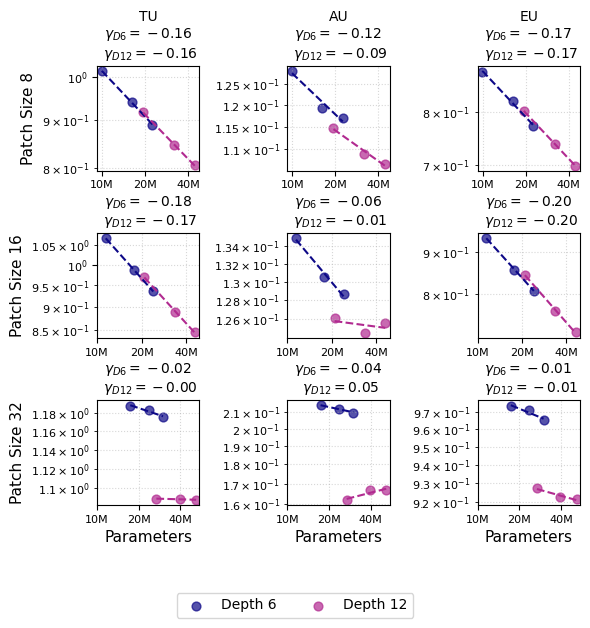

In [6]:
# Configuration
metrics = ["val/tu", "val/au", "val/eu"]
metric_names = ["TU", "AU", "EU"]
patch_sizes = sorted(df["patch_size"].unique())
depths = sorted(df["depth"].unique())
colors = plt.cm.plasma(np.linspace(0, 0.8, len(depths)))

fig, axes = plt.subplots(len(patch_sizes), 3, 
                         figsize=(6, 2 * len(patch_sizes)), 
                         sharex=False, sharey=False, squeeze=False)

# Track handles for the global legend
depth_handles = {}

for row_idx, ps in enumerate(patch_sizes):
    ps_df = df[df["patch_size"] == ps]
    
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        slopes_text = []
        
        for d_idx, d_val in enumerate(depths):
            data = ps_df[ps_df["depth"] == d_val].sort_values("parameters")
            if data.empty: continue
            
            mean_data = data.groupby("parameters")[metric].mean().reset_index()
            x, y = mean_data["parameters"].values, mean_data[metric].values
            
            mask = (x > 0) & (y > 0)
            if mask.sum() > 1:
                slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = np.exp(slope * np.log(x_fit) + intercept)
                
                # Plot points and line
                sc = ax.scatter(x, y, color=colors[d_idx], alpha=0.7, s=40)
                line, = ax.plot(x_fit, y_fit, color=colors[d_idx], linestyle="--", linewidth=1.5)
                
                # Store handle for depth legend (only once)
                if d_val not in depth_handles:
                    depth_handles[d_val] = sc
                
                # Collect slope for title
                slopes_text.append(rf"$\gamma_{{D{d_val}}}={slope:.2f}$")

        # Subplot Aesthetics
        ax.set_xscale("log")
        ax.set_yscale("log")
        
        # Title: Metric Name + Scaling Exponents
        title_prefix = f"{metric_names[col_idx]}" if row_idx == 0 else ""
        ax.set_title(f"{title_prefix}\n" + " \n ".join(slopes_text), fontsize=10)
        
        if col_idx == 0:
            ax.set_ylabel(f"Patch Size {ps}", fontsize=11)
            
        if row_idx == len(patch_sizes) - 1:
            ax.set_xlabel("Parameters", fontsize=11)

        # Log Ticks
        ax.xaxis.set_major_locator(NullLocator())
        ax.xaxis.set_minor_locator(NullLocator())
        ticks = [10e6, 20e6, 40e6]
        ax.set_xticks(ticks, [f"{t/1e6:.0f}M" for t in ticks])
        #ax.yaxis.set_major_locator(NullLocator())
        #ax.yaxis.set_minor_locator(NullLocator())
        #ax.set_yticks((0.1, 1), ("0.1", "1"))

        ax.grid(True, which="both", linestyle=":", alpha=0.5)

# Add a single common legend for Depth at the bottom
sorted_depths = sorted(depth_handles.keys())
fig.legend(
    [depth_handles[d] for d in sorted_depths], 
    [f"Depth {d}" for d in sorted_depths],
    loc="lower center", 
    ncol=len(sorted_depths), 
    bbox_to_anchor=(0.5, -0.05),
    frameon=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, hspace=0.6)
plt.show()

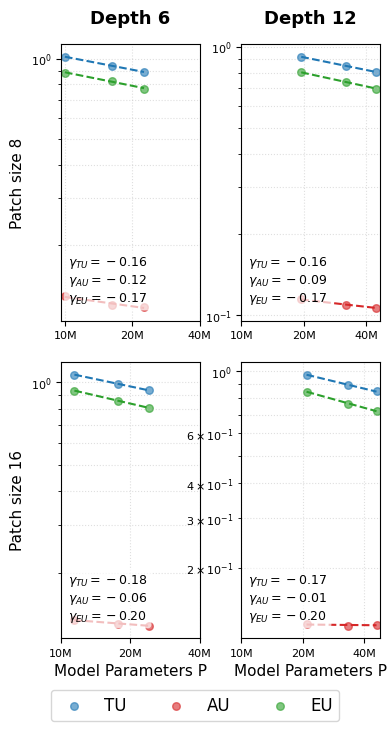

In [17]:
df_plot = df[(df["patch_size"] != 32) & (df["depth"] != 24)].copy()

# 2. Configuration
metrics = ["val/tu", "val/au", "val/eu"]
metric_names = ["TU", "AU", "EU"]
patch_sizes = sorted(df_plot["patch_size"].unique())
depths = sorted(df_plot["depth"].unique())

# Use distinct colors for the three metrics
metric_colors = ["#1f77b4", "#d62728", "#2ca02c"] # Blue, Red, Green

# Grid: Rows = Patch Sizes, Cols = Depths
fig, axes = plt.subplots(len(patch_sizes), len(depths), 
                         figsize=(2 * len(depths), 3.5 * len(patch_sizes)), 
                         sharex=False, sharey=False, squeeze=False)

# Track handles for the global metric legend
metric_handles = {}

for row_idx, ps in enumerate(patch_sizes):
    for col_idx, d_val in enumerate(depths):
        ax = axes[row_idx, col_idx]
        slopes_text = []
        
        # Subset for this specific subplot
        subset = df_plot[(df_plot["patch_size"] == ps) & (df_plot["depth"] == d_val)]
        
        for m_idx, metric in enumerate(metrics):
            data = subset.sort_values("parameters")
            if data.empty: continue
            
            # Group by parameters to handle multiple runs/seeds
            mean_data = data.groupby("parameters")[metric].mean().reset_index()
            x, y = mean_data["parameters"].values, mean_data[metric].values
            
            # Linear regression in log-log space
            mask = (x > 0) & (y > 0)
            if mask.sum() > 1:
                slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = np.exp(slope * np.log(x_fit) + intercept)
                
                # Plot points and regression line
                sc = ax.scatter(x, y, color=metric_colors[m_idx], alpha=0.6, s=30)
                ax.plot(x_fit, y_fit, color=metric_colors[m_idx], linestyle="--", linewidth=1.5)
                
                # Store handle for the legend
                if metric_names[m_idx] not in metric_handles:
                    metric_handles[metric_names[m_idx]] = sc
                
                # Collect slope for the annotation
                slopes_text.append(rf"$\gamma_{{{metric_names[m_idx]}}}={slope:.2f}$")

        # --- Subplot Aesthetics ---
        ax.set_xscale("log")
        ax.set_yscale("log")
        
        # Titles: Depth on top row, Slopes inside the plot
        if row_idx == 0:
            ax.set_title(f"Depth {d_val}", fontsize=13, fontweight='bold', pad=15)
        
        # Add a text box for slopes
        if slopes_text:
            ax.text(0.05, 0.05, "\n".join(slopes_text), transform=ax.transAxes, 
                    fontsize=9, verticalalignment='bottom', 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="none"))

        if col_idx == 0:
            ax.set_ylabel(f"Patch size {ps}", fontsize=11)
            
        if row_idx == len(patch_sizes) - 1:
            ax.set_xlabel("Model Parameters P", fontsize=11)

        # Clean up X-axis ticks
        ax.xaxis.set_major_locator(NullLocator())
        ax.xaxis.set_minor_locator(NullLocator())
        ticks = [10e6, 20e6, 40e6]
        ax.set_xticks(ticks, [f"{t/1e6:.0f}M" for t in ticks])
        ax.grid(True, which="both", linestyle=":", alpha=0.4)

# 3. Add a single common legend for the Metrics
fig.legend(
    [metric_handles[name] for name in metric_names if name in metric_handles], 
    metric_names,
    loc="lower center", 
    ncol=3, 
    bbox_to_anchor=(0.5, -0.05),
    frameon=True,
    fontsize=12
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, hspace=0.15, wspace=0.3)
plt.show()